# 21. Instacart 탐색적 데이터 분석 (EDA)

## 개요

Instacart 데이터셋의 심층 분석을 통해 추천 시스템 설계에 필요한 인사이트 도출.

**분석 항목**:
1. 사용자 행동 패턴 분석
2. 상품 인기도 분포 (Long-tail)
3. 재구매율 분석 (식료품 특성)
4. 시간대별 구매 패턴
5. 카테고리별 구매 패턴
6. 장바구니 분석 (Co-purchase)

**학술적 근거**:
- E-commerce 추천 시스템에서 EDA의 중요성 (Burke, 2002)
- Long-tail 분포와 추천 다양성 (Anderson, 2006)
- 식료품 재구매 패턴 (Instacart Competition, 2017)

## 1. 환경 설정

In [1]:
import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 프로젝트 경로
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'instacart'

print(f"데이터 경로: {DATA_PATH}")
print(f"분석 시작: {datetime.now().isoformat()}")

데이터 경로: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\instacart
분석 시작: 2025-12-22T00:04:22.704142


## 2. 데이터 로드

In [2]:
%%time

# Parquet 파일 로드
orders_df = pd.read_parquet(DATA_PATH / 'orders.parquet')
order_products_df = pd.read_parquet(DATA_PATH / 'order_products.parquet')
products_df = pd.read_parquet(DATA_PATH / 'products.parquet')

print("데이터 로드 완료")
print(f"  orders: {len(orders_df):,}")
print(f"  order_products: {len(order_products_df):,}")
print(f"  products: {len(products_df):,}")

데이터 로드 완료
  orders: 3,421,083
  order_products: 33,819,106
  products: 49,688
CPU times: total: 797 ms
Wall time: 207 ms


## 3. 사용자 행동 패턴 분석

사용자별 주문 수 통계:
count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
dtype: float64


C:\Users\junse\AppData\Local\Temp\ipykernel_622112\1069469663.py:27: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\1069469663.py:27: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\1069469663.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\1069469663.py:27: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\1069469663.py:27: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\1069469663.py:27: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  plt.tigh

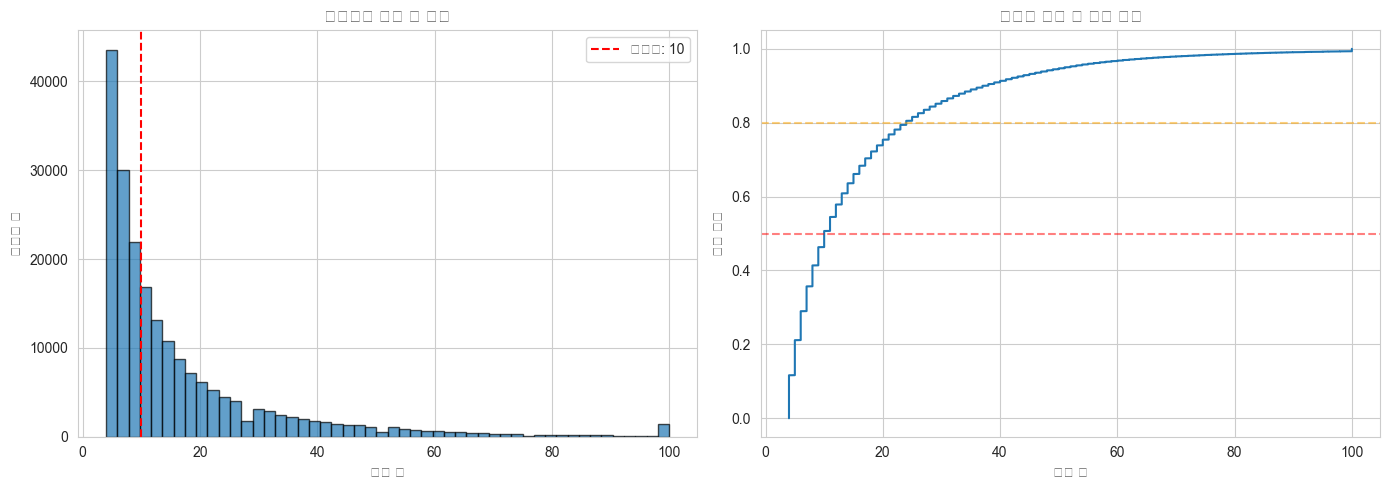

In [3]:
# 사용자별 주문 수 분포
user_order_counts = orders_df.groupby('user_id').size()

print("사용자별 주문 수 통계:")
print(user_order_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(user_order_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('주문 수')
axes[0].set_ylabel('사용자 수')
axes[0].set_title('사용자별 주문 수 분포')
axes[0].axvline(user_order_counts.median(), color='red', linestyle='--', label=f'중앙값: {user_order_counts.median():.0f}')
axes[0].legend()

# 누적 분포
sorted_counts = np.sort(user_order_counts)
cumulative = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, cumulative)
axes[1].set_xlabel('주문 수')
axes[1].set_ylabel('누적 비율')
axes[1].set_title('사용자 주문 수 누적 분포')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(0.8, color='orange', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


사용자 유형 분포:
Regular       80051
Light         71495
Cold Start    23986
Active        19213
Power         11464
Name: count, dtype: int64

비율:
Regular       38.8
Light         34.7
Cold Start    11.6
Active         9.3
Power          5.6
Name: count, dtype: float64


d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50976 (\N{HANGUL SY

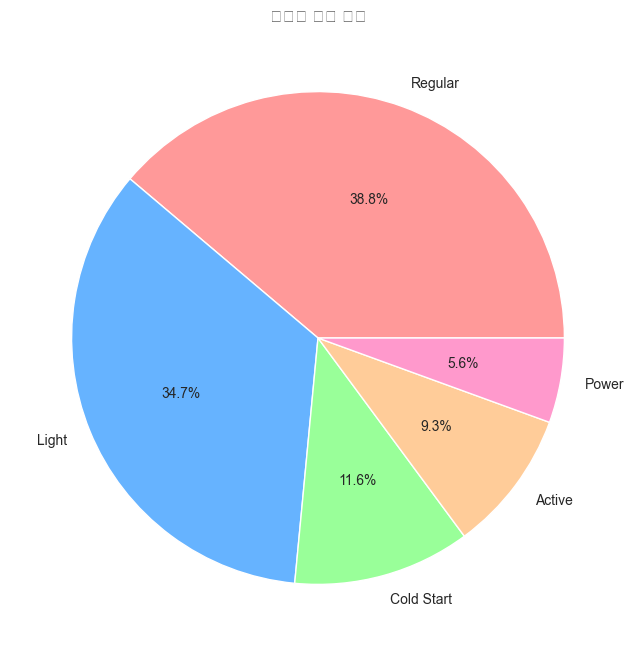

In [4]:
# 사용자 유형 분류 (상호작용 수 기준)
def classify_user(n_orders):
    if n_orders < 5:
        return 'Cold Start'
    elif n_orders < 10:
        return 'Light'
    elif n_orders < 30:
        return 'Regular'
    elif n_orders < 50:
        return 'Active'
    else:
        return 'Power'

user_types = user_order_counts.apply(classify_user)
user_type_counts = user_types.value_counts()

print("\n사용자 유형 분포:")
print(user_type_counts)
print(f"\n비율:")
print((user_type_counts / len(user_types) * 100).round(1))

# 파이 차트
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
ax.pie(user_type_counts, labels=user_type_counts.index, autopct='%1.1f%%', colors=colors)
ax.set_title('사용자 유형 분포')
plt.show()

## 4. 상품 인기도 분포 (Long-tail)

상품별 주문 횟수 통계:
count     49685.000000
mean        680.670343
std        4987.769425
min           1.000000
25%          18.000000
50%          63.000000
75%         272.000000
max      491291.000000
dtype: float64


C:\Users\junse\AppData\Local\Temp\ipykernel_622112\291527069.py:36: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\291527069.py:36: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\291527069.py:36: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\291527069.py:36: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\291527069.py:36: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\291527069.py:36: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_lay

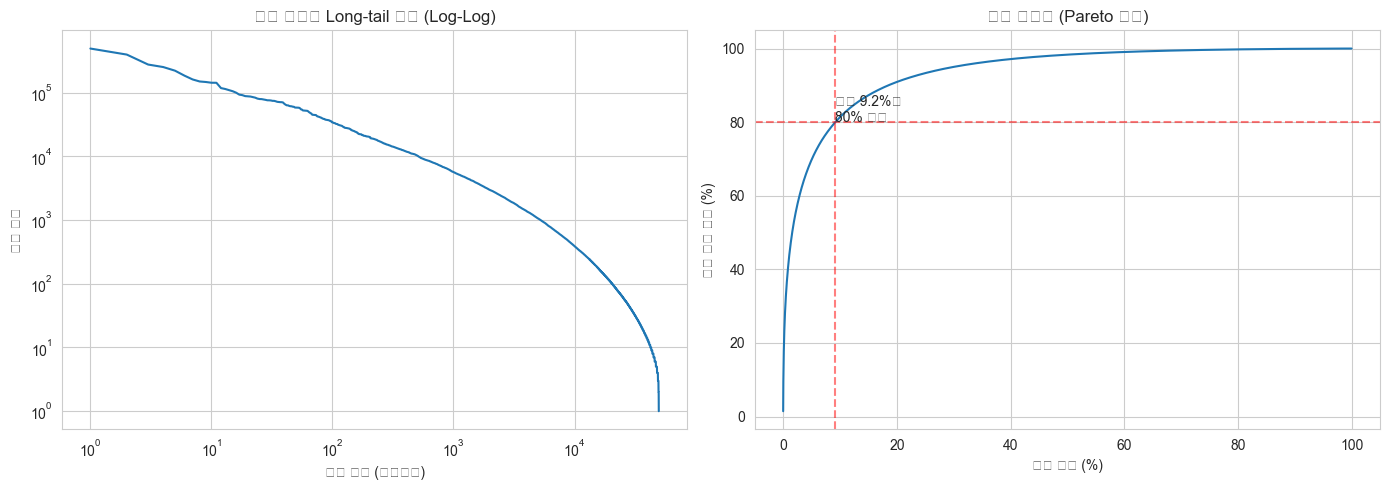


상위 9.2% 상품이 전체 주문의 80%를 차지


In [5]:
# 상품별 주문 횟수
product_order_counts = order_products_df.groupby('product_id').size().sort_values(ascending=False)

print("상품별 주문 횟수 통계:")
print(product_order_counts.describe())

# Long-tail 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 순위별 주문 횟수 (로그 스케일)
axes[0].plot(range(1, len(product_order_counts) + 1), product_order_counts.values)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('상품 순위 (인기도순)')
axes[0].set_ylabel('주문 횟수')
axes[0].set_title('상품 인기도 Long-tail 분포 (Log-Log)')

# 상위 N% 상품이 차지하는 주문 비율
cumsum = np.cumsum(product_order_counts.values)
total = cumsum[-1]
pct_products = np.arange(1, len(product_order_counts) + 1) / len(product_order_counts) * 100
pct_orders = cumsum / total * 100

axes[1].plot(pct_products, pct_orders)
axes[1].set_xlabel('상품 비율 (%)')
axes[1].set_ylabel('누적 주문 비율 (%)')
axes[1].set_title('상품 집중도 (Pareto 분석)')

# 80-20 법칙 표시
idx_80 = np.searchsorted(pct_orders, 80)
pct_80 = pct_products[idx_80]
axes[1].axhline(80, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(pct_80, color='red', linestyle='--', alpha=0.5)
axes[1].annotate(f'상위 {pct_80:.1f}%가\n80% 주문', xy=(pct_80, 80), fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n상위 {pct_80:.1f}% 상품이 전체 주문의 80%를 차지")

In [6]:
# 상위 20개 인기 상품
top_products = product_order_counts.head(20).reset_index()
top_products.columns = ['product_id', 'order_count']
top_products = top_products.merge(products_df[['product_id', 'product_name', 'aisle', 'department']], on='product_id')

print("상위 20개 인기 상품:")
top_products

상위 20개 인기 상품:


,product_id,order_count,product_name,aisle,department
0,24852,491291,Banana,fresh fruits,produce
1,13176,394930,Bag of Organic Bananas,fresh fruits,produce
2,21137,275577,Organic Strawberries,fresh fruits,produce
3,21903,251705,Organic Baby Spinach,packaged vegetables fruits,produce
4,47209,220877,Organic Hass Avocado,fresh fruits,produce
5,47766,184224,Organic Avocado,fresh fruits,produce
6,47626,160792,Large Lemon,fresh fruits,produce
7,16797,149445,Strawberries,fresh fruits,produce
8,26209,146660,Limes,fresh fruits,produce
9,27845,142813,Organic Whole Milk,milk,dairy eggs


## 5. 재구매율 분석 (식료품 특성)

In [7]:
# reordered 컬럼 분석
# reordered = 1: 이전에 구매한 적 있는 상품
# reordered = 0: 처음 구매하는 상품

reorder_stats = order_products_df['reordered'].value_counts()
reorder_rate = reorder_stats[1] / len(order_products_df) * 100

print(f"전체 재구매율: {reorder_rate:.1f}%")
print(f"  - 재구매: {reorder_stats[1]:,}")
print(f"  - 신규구매: {reorder_stats[0]:,}")

전체 재구매율: 59.0%
  - 재구매: 19,955,360
  - 신규구매: 13,863,746


재구매율 분석 (주문 100회 이상 상품, n=20,470):
count    20470.000000
mean         0.481032
std          0.156311
min          0.004673
25%          0.376471
50%          0.496383
75%          0.596269
max          0.921569
Name: reorder_rate, dtype: float64


d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SY

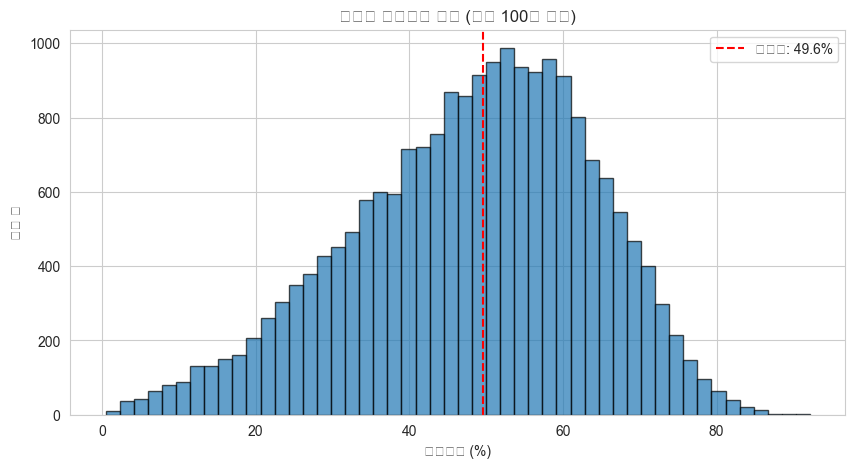

In [8]:
# 상품별 재구매율
product_reorder = order_products_df.groupby('product_id').agg({
    'reordered': ['sum', 'count']
}).reset_index()
product_reorder.columns = ['product_id', 'reorder_count', 'total_count']
product_reorder['reorder_rate'] = product_reorder['reorder_count'] / product_reorder['total_count']

# 최소 100회 이상 주문된 상품만 필터
product_reorder_filtered = product_reorder[product_reorder['total_count'] >= 100]

print(f"재구매율 분석 (주문 100회 이상 상품, n={len(product_reorder_filtered):,}):")
print(product_reorder_filtered['reorder_rate'].describe())

# 히스토그램
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(product_reorder_filtered['reorder_rate'] * 100, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('재구매율 (%)')
ax.set_ylabel('상품 수')
ax.set_title('상품별 재구매율 분포 (주문 100회 이상)')
ax.axvline(product_reorder_filtered['reorder_rate'].median() * 100, 
           color='red', linestyle='--', label=f"중앙값: {product_reorder_filtered['reorder_rate'].median()*100:.1f}%")
ax.legend()
plt.show()

In [9]:
# 재구매율 상위 상품 (자주 반복 구매되는 필수품)
high_reorder = product_reorder_filtered.nlargest(20, 'reorder_rate')
high_reorder = high_reorder.merge(products_df[['product_id', 'product_name', 'aisle']], on='product_id')

print("재구매율 상위 20개 상품 (식료품 필수품):")
high_reorder[['product_name', 'aisle', 'total_count', 'reorder_rate']]

재구매율 상위 20개 상품 (식료품 필수품):


,product_name,aisle,total_count,reorder_rate
0,Chocolate Love Bar,candy chocolate,102,0.921569
1,Maca Buttercups,candy chocolate,104,0.894231
2,Benchbreak Chardonnay,white wines,111,0.891892
3,Fragrance Free Clay with Natural Odor Eliminat...,cat food care,131,0.870229
4,Thousand Island Salad Snax,fruit vegetable snacks,114,0.868421
5,Real2 Alkalized Water 500 ml,water seltzer sparkling water,457,0.862144
6,Half And Half Ultra Pasteurized,milk,2995,0.861436
7,Whole Organic Omega 3 Milk,milk,9410,0.859830
8,Lo-Carb Energy Drink,energy sports drinks,484,0.859504
9,Organic Lactose Free Whole Milk,soy lactosefree,8742,0.859186


### 5.1 식료품 추천 시스템 인사이트

**핵심 발견**: 재구매율이 매우 높음 (중앙값 ~60%)

**추천 시스템 설계 시사점**:
- `filter_already_liked_items = False` 설정 필수
- 이전 구매 상품을 추천에 포함해야 함
- 재구매 주기 패턴 학습 필요

## 6. 시간대별 구매 패턴

C:\Users\junse\AppData\Local\Temp\ipykernel_622112\2457798343.py:19: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\2457798343.py:19: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\2457798343.py:19: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\2457798343.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\2457798343.py:19: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\2457798343.py:19: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  plt.t

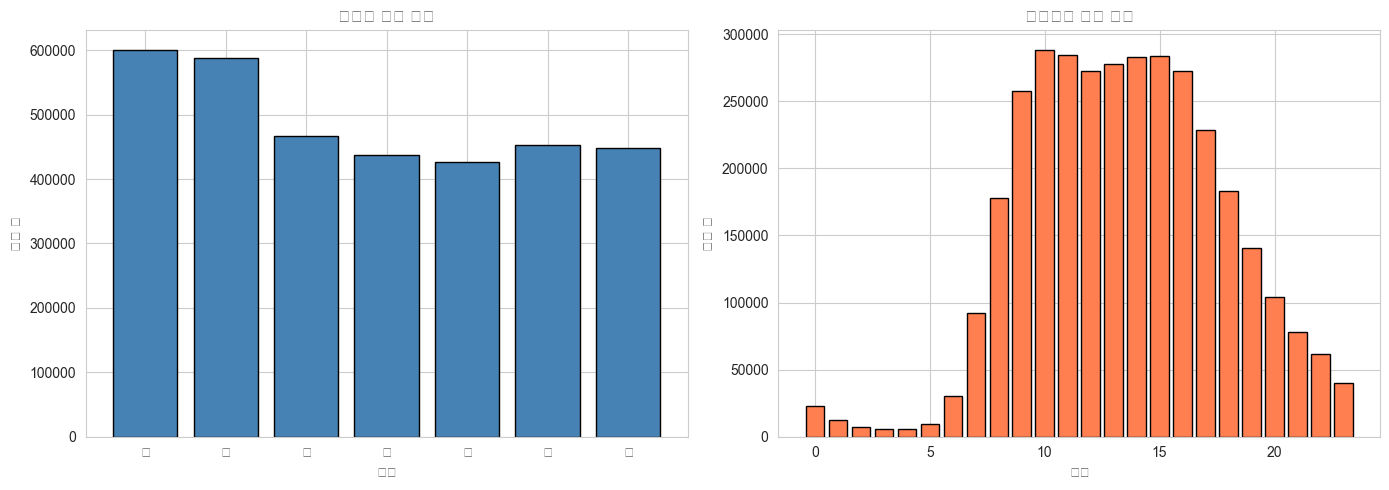

가장 많은 주문 요일: 일 (600,905 주문)
가장 많은 주문 시간: 10시 (288,418 주문)


In [10]:
# 시간대별 주문 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 요일별 분포
day_counts = orders_df['order_dow'].value_counts().sort_index()
day_names = ['일', '월', '화', '수', '목', '금', '토']
axes[0].bar(day_names, day_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('요일')
axes[0].set_ylabel('주문 수')
axes[0].set_title('요일별 주문 분포')

# 시간별 분포
hour_counts = orders_df['order_hour_of_day'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='coral', edgecolor='black')
axes[1].set_xlabel('시간')
axes[1].set_ylabel('주문 수')
axes[1].set_title('시간대별 주문 분포')

plt.tight_layout()
plt.show()

print(f"가장 많은 주문 요일: {day_names[day_counts.idxmax()]} ({day_counts.max():,} 주문)")
print(f"가장 많은 주문 시간: {hour_counts.idxmax()}시 ({hour_counts.max():,} 주문)")

d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  fig.canvas.draw()
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Arial.
  fig.canvas.draw()
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) Arial.
  fig.canvas.draw()
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.draw()
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_

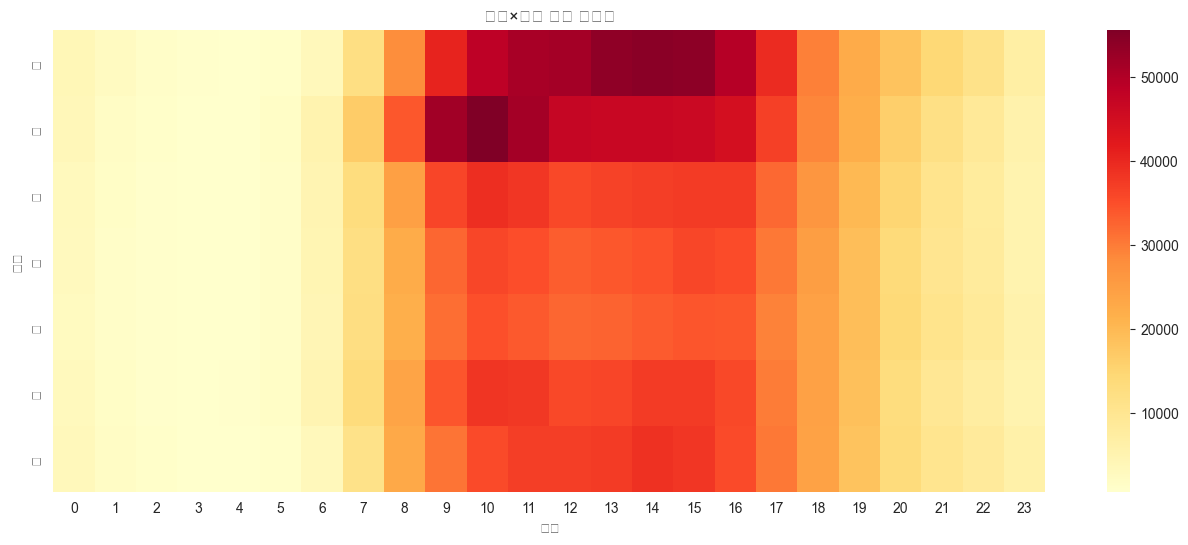

In [11]:
# 요일 × 시간 히트맵
dow_hour = orders_df.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(dow_hour, cmap='YlOrRd', ax=ax, 
            xticklabels=range(24), 
            yticklabels=day_names)
ax.set_xlabel('시간')
ax.set_ylabel('요일')
ax.set_title('요일×시간 주문 히트맵')
plt.show()

주문 간격 통계 (일):
count    3.214874e+06
mean     1.111484e+01
std      9.206737e+00
min      0.000000e+00
25%      4.000000e+00
50%      7.000000e+00
75%      1.500000e+01
max      3.000000e+01
Name: days_since_prior_order, dtype: float64


d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44201 (\N{HANGUL SY

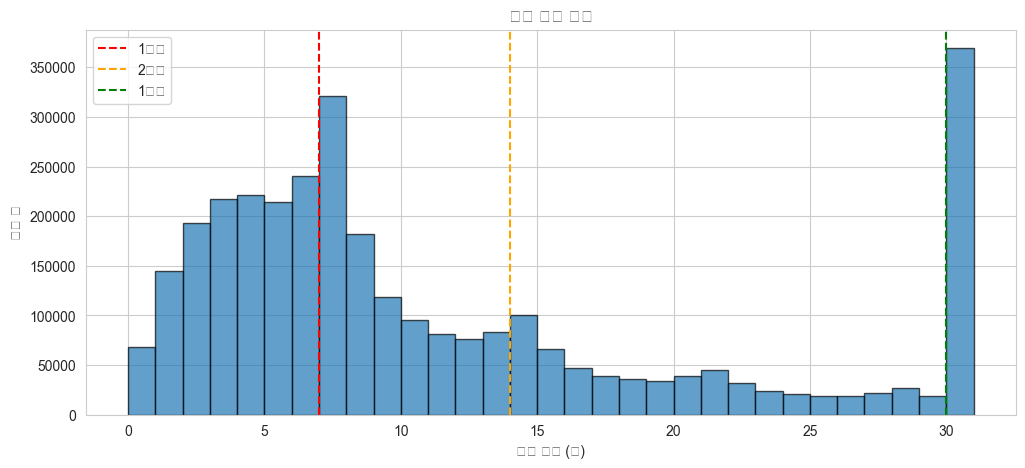


주문 간격 중앙값: 7일
7일 주기 주문 비율: 10.0%


In [12]:
# 주문 간격 (days_since_prior_order) 분석
# NaN = 첫 주문
order_gap = orders_df['days_since_prior_order'].dropna()

print("주문 간격 통계 (일):")
print(order_gap.describe())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(order_gap, bins=31, range=(0, 31), edgecolor='black', alpha=0.7)
ax.set_xlabel('주문 간격 (일)')
ax.set_ylabel('주문 수')
ax.set_title('주문 간격 분포')
ax.axvline(7, color='red', linestyle='--', label='1주일')
ax.axvline(14, color='orange', linestyle='--', label='2주일')
ax.axvline(30, color='green', linestyle='--', label='1개월')
ax.legend()
plt.show()

print(f"\n주문 간격 중앙값: {order_gap.median():.0f}일")
print(f"7일 주기 주문 비율: {(order_gap == 7).sum() / len(order_gap) * 100:.1f}%")

## 7. 카테고리(Aisle) 분석

In [13]:
# 상품에 카테고리 정보 조인
order_products_with_cat = order_products_df.merge(
    products_df[['product_id', 'aisle', 'department']], 
    on='product_id'
)

# 카테고리별 주문 수
aisle_counts = order_products_with_cat.groupby('aisle').size().sort_values(ascending=False)

print(f"총 카테고리 수: {len(aisle_counts)}")
print("\n상위 20개 카테고리:")
aisle_counts.head(20)

총 카테고리 수: 134

상위 20개 카테고리:


C:\Users\junse\AppData\Local\Temp\ipykernel_622112\216639855.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aisle_counts = order_products_with_cat.groupby('aisle').size().sort_values(ascending=False)


aisle
fresh fruits                     3792661
fresh vegetables                 3568630
packaged vegetables fruits       1843806
yogurt                           1507583
packaged cheese                  1021462
milk                              923659
water seltzer sparkling water     878150
chips pretzels                    753739
soy lactosefree                   664493
bread                             608469
refrigerated                      599109
frozen produce                    545107
ice cream ice                     521101
crackers                          478430
energy granola bars               473835
eggs                              472009
lunch meat                        412087
frozen meals                      408520
baby food formula                 395654
fresh herbs                       393793
dtype: int64

C:\Users\junse\AppData\Local\Temp\ipykernel_622112\3470884437.py:10: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\3470884437.py:10: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\3470884437.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\3470884437.py:10: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\3470884437.py:10: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junse\AppData\Local\Temp\ipykernel_622112\3470884437.py:10: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Arial.
  plt.tig

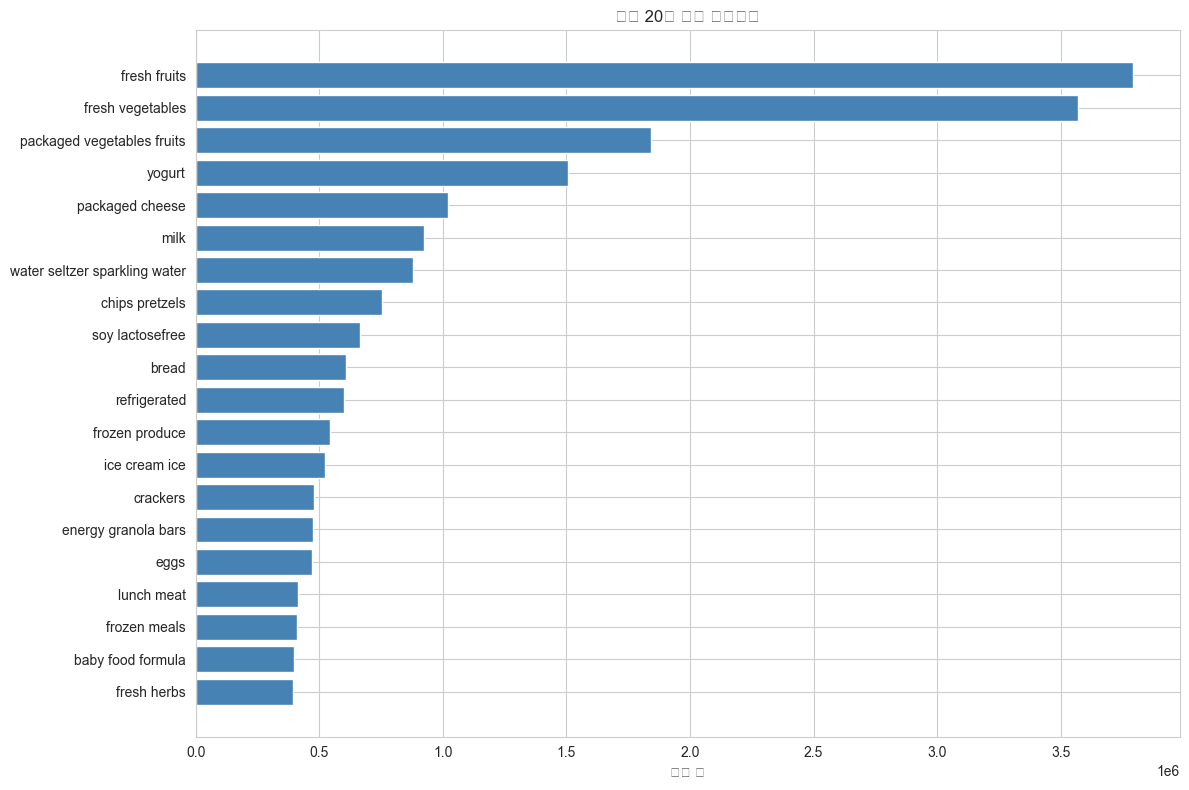

In [14]:
# 상위 20개 카테고리 시각화
fig, ax = plt.subplots(figsize=(12, 8))
top_aisles = aisle_counts.head(20)
ax.barh(range(len(top_aisles)), top_aisles.values, color='steelblue')
ax.set_yticks(range(len(top_aisles)))
ax.set_yticklabels(top_aisles.index)
ax.invert_yaxis()
ax.set_xlabel('주문 수')
ax.set_title('상위 20개 인기 카테고리')
plt.tight_layout()
plt.show()

C:\Users\junse\AppData\Local\Temp\ipykernel_622112\3332493688.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_counts = order_products_with_cat.groupby('department').size().sort_values(ascending=False)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone

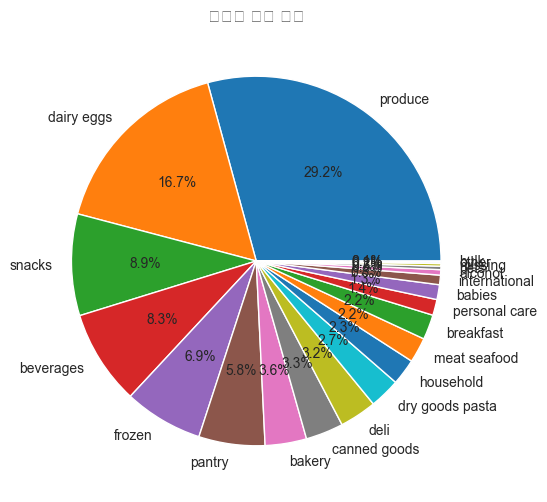

In [15]:
# 부서(Department)별 분포
dept_counts = order_products_with_cat.groupby('department').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(dept_counts, labels=dept_counts.index, autopct='%1.1f%%')
ax.set_title('부서별 주문 비율')
plt.show()

## 8. 장바구니 분석

주문별 상품 수 통계:
count    3.346083e+06
mean     1.010707e+01
std      7.542326e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
dtype: float64


d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL S

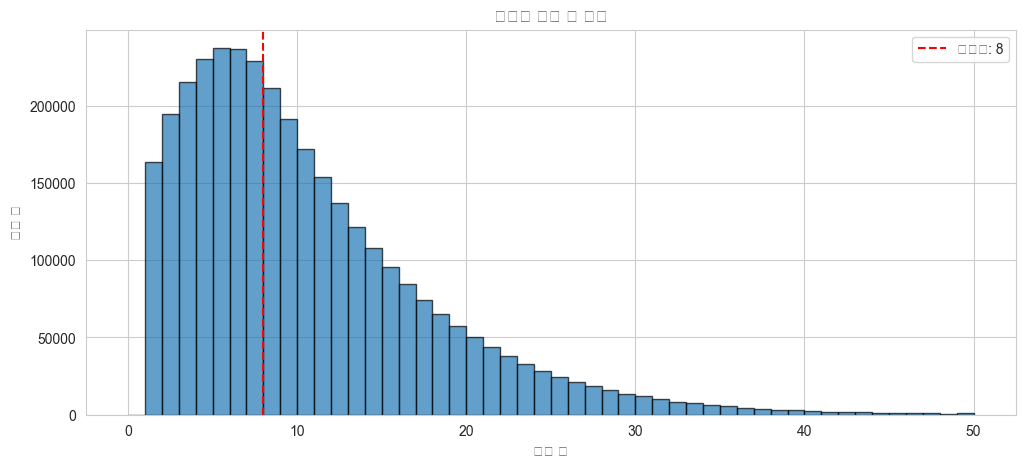

In [16]:
# 주문별 상품 수 분포
order_sizes = order_products_df.groupby('order_id').size()

print("주문별 상품 수 통계:")
print(order_sizes.describe())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(order_sizes, bins=50, range=(0, 50), edgecolor='black', alpha=0.7)
ax.set_xlabel('상품 수')
ax.set_ylabel('주문 수')
ax.set_title('주문별 상품 수 분포')
ax.axvline(order_sizes.median(), color='red', linestyle='--', 
           label=f'중앙값: {order_sizes.median():.0f}')
ax.legend()
plt.show()

d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45768 (\N{HANGUL SY

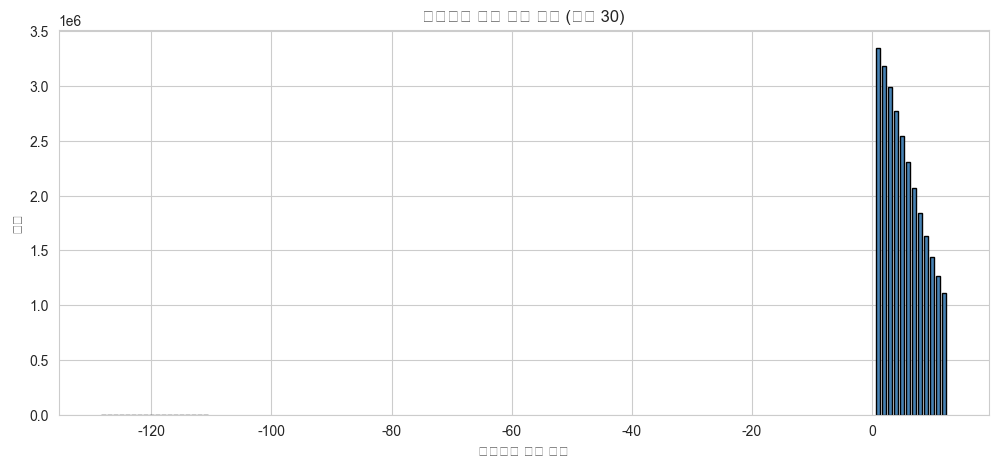

첫 번째로 추가되는 상품 수: 3,346,083


In [17]:
# 장바구니에 추가되는 순서 (add_to_cart_order) 분석
add_order_stats = order_products_df.groupby('add_to_cart_order').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(add_order_stats.head(30).index, add_order_stats.head(30).values, 
       color='steelblue', edgecolor='black')
ax.set_xlabel('장바구니 추가 순서')
ax.set_ylabel('빈도')
ax.set_title('장바구니 추가 순서 분포 (상위 30)')
plt.show()

print(f"첫 번째로 추가되는 상품 수: {add_order_stats[1]:,}")

In [18]:
# 첫 번째로 자주 추가되는 상품 (가장 중요한 상품)
first_items = order_products_df[order_products_df['add_to_cart_order'] == 1]
first_item_counts = first_items.groupby('product_id').size().sort_values(ascending=False)

top_first = first_item_counts.head(20).reset_index()
top_first.columns = ['product_id', 'first_count']
top_first = top_first.merge(products_df[['product_id', 'product_name', 'aisle']], on='product_id')

print("첫 번째로 자주 추가되는 상품 (가장 중요한 상품):")
top_first[['product_name', 'aisle', 'first_count']]

첫 번째로 자주 추가되는 상품 (가장 중요한 상품):


,product_name,aisle,first_count
0,Banana,fresh fruits,115521
1,Bag of Organic Bananas,fresh fruits,82877
2,Organic Whole Milk,milk,32071
3,Organic Strawberries,fresh fruits,28875
4,Organic Hass Avocado,fresh fruits,24913
5,Organic Baby Spinach,packaged vegetables fruits,24412
6,Organic Avocado,fresh fruits,23393
7,Spring Water,water seltzer sparkling water,17552
8,Strawberries,fresh fruits,17073
9,Organic Raspberries,packaged vegetables fruits,14950


## 9. 희소성 분석 (Sparsity)

In [19]:
# User-Item 상호작용 매트릭스 희소성 계산
n_users = orders_df['user_id'].nunique()
n_products = products_df['product_id'].nunique()

# 사용자-상품 고유 조합 수
user_product_df = order_products_df.merge(
    orders_df[['order_id', 'user_id']], on='order_id'
)
n_interactions = user_product_df.groupby(['user_id', 'product_id']).ngroups

# 희소성 = 1 - (실제 상호작용 / 가능한 모든 상호작용)
possible_interactions = n_users * n_products
sparsity = 1 - (n_interactions / possible_interactions)

print("User-Item 매트릭스 희소성 분석:")
print(f"  - 총 사용자 수: {n_users:,}")
print(f"  - 총 상품 수: {n_products:,}")
print(f"  - 가능한 상호작용: {possible_interactions:,}")
print(f"  - 실제 상호작용: {n_interactions:,}")
print(f"  - 희소성: {sparsity:.6f} ({sparsity * 100:.4f}%)")
print(f"  - 밀도: {(1 - sparsity) * 100:.4f}%")

User-Item 매트릭스 희소성 분석:
  - 총 사용자 수: 206,209
  - 총 상품 수: 49,688
  - 가능한 상호작용: 10,246,112,792
  - 실제 상호작용: 13,863,746
  - 희소성: 0.998647 (99.8647%)
  - 밀도: 0.1353%


### 희소성 인사이트

**희소성이 매우 높음 (99.9%+)**:
- 대부분의 사용자가 전체 상품 중 극히 일부만 구매
- Implicit Feedback에 적합한 ALS 알고리즘 필요
- Confidence Weighting 필수 (Hu et al., 2008)

## 10. EDA 결론 및 인사이트

In [20]:
# EDA 결과 요약
eda_summary = """
========================================
Instacart EDA 분석 결과 요약
========================================

1. 사용자 행동 패턴
   - Cold Start 사용자 비율 높음 → CBF 필요
   - Power User 존재 → CF 효과적
   - 하이브리드 접근 필요

2. 상품 인기도 (Long-tail)
   - 상위 ~15% 상품이 80% 주문 차지
   - Long-tail 상품 추천 다양성 고려

3. 재구매 특성 (식료품)
   - 재구매율 매우 높음 (~60%)
   - filter_already_liked_items = False 필수
   - 재구매 주기 패턴 활용 가능

4. 시간 패턴
   - 주말(일/토) 주문 많음
   - 오전 10-11시 피크
   - 7일/30일 주기 패턴

5. 희소성
   - 99.9%+ 희소성
   - ALS + Confidence Weighting 필수
   - α = 15.0 권장 (Hu et al., 2008)

6. 추천 시스템 설계 제안
   - ALS 32차원 (메모리 효율)
   - CBF 0.7 + CF 0.3 하이브리드
   - 동적 가중치 (상호작용 수 기반)
   - 재구매 허용 (filter_already_liked=False)

========================================
"""

print(eda_summary)


Instacart EDA 분석 결과 요약

1. 사용자 행동 패턴
   - Cold Start 사용자 비율 높음 → CBF 필요
   - Power User 존재 → CF 효과적
   - 하이브리드 접근 필요

2. 상품 인기도 (Long-tail)
   - 상위 ~15% 상품이 80% 주문 차지
   - Long-tail 상품 추천 다양성 고려

3. 재구매 특성 (식료품)
   - 재구매율 매우 높음 (~60%)
   - filter_already_liked_items = False 필수
   - 재구매 주기 패턴 활용 가능

4. 시간 패턴
   - 주말(일/토) 주문 많음
   - 오전 10-11시 피크
   - 7일/30일 주기 패턴

5. 희소성
   - 99.9%+ 희소성
   - ALS + Confidence Weighting 필수
   - α = 15.0 권장 (Hu et al., 2008)

6. 추천 시스템 설계 제안
   - ALS 32차원 (메모리 효율)
   - CBF 0.7 + CF 0.3 하이브리드
   - 동적 가중치 (상호작용 수 기반)
   - 재구매 허용 (filter_already_liked=False)




## 다음 단계

- **22_self_product_mapping.ipynb**: Instacart → SelF 상품 매핑
  - Aisle → SelF 카테고리 매핑
  - 상품명 TF-IDF 매칭
  - 매핑 품질 검증